<a href="https://colab.research.google.com/github/gitmystuff/INFO5810/blob/main/Module_03-Vectors/Vectors_and_Meaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vectors and Meaning

## Getting Started

* Colab - get notebook from gitmystuff DTSC5810 repository
* Save a Copy in Drive
* Remove Copy of
* Edit your name in the cell above and the filename
* Clean up Colab Notebooks folder
* Submit shared link

## A Side Note: Geometry, History, and Where "Knowledge Discovery" Comes From

**A row of numbers is a point in space, and "understanding" is figuring out that point's position, direction, or distance relative to other points.** Geometry turns out to be a genuinely unifying language across almost every modern AI and data tool -- probability distributions are shapes, coefficients and eigenvectors, introduced today, are both vectors doing different jobs, the curse of dimensionality is a statement about collapsing distances, and this talk on embeddings make the whole idea literal by turning *meaning itself* into a point in space.

Everything so far has treated relationships between data points as *implicit* -- inferred from distance, covariance, or, as we'll see today, angle. Starting soon, those relationships become **explicit** -- knowledge represented as connected facts (triples, ontologies, graphs) rather than a cloud of points. This isn't a departure from the geometric thread; it's the next chapter of it. Knowledge graph embeddings are the same "row becomes a point" idea applied to graph nodes. Graph Neural Networks lean on a graph's own version of a covariance matrix (the graph Laplacian) and its eigenvectors -- the exact same math, just computed on connectivity instead of features. A graph is what happens when you stop asking "how close are these points" and start asking "why" -- and you can still answer that second question with the eigenvectors you already know.

**A brief word on where this geometric approach sits historically.** Rows of data have always secretly been geometric objects -- a "feature vector" in classical machine learning, an "observation" in classical statistics, both already implicit point-in-space language. What's genuinely new isn't the geometry itself, but *where the points come from*: hand-chosen features versus features learned automatically from raw data. The older, traditional approach to knowledge discovery was rule-based and query-driven -- relational databases, hand-authored ontologies, expert systems with explicit if-then logic -- powerful for structured data, but brittle with anything that didn't fit neatly into predefined categories (free text, fuzzy relationships, meaning that resists exact keyword matching). It's worth knowing this geometric, structural tradition has real roots too: Sewall Wright's path analysis in the 1920s treated relationships between variables as explicit diagrams and directions, decades before graph-based causal models caught on -- an approach that was largely sidelined in mainstream statistics teaching for much of the 20th century, in part due to Ronald Fisher's institutional dominance and a well-documented rivalry between the two. The geometric perspective for us ultimately arrived through a separate lineage -- linear algebra and machine learning -- but it's a useful reminder that today's "modern" AI toolkit has intellectual ancestors stretching back a century, not just the last few years.

## Where We've Been

Recall the KDD pipeline from Module 1: **Selection → Preprocessing → Transformation → Data Mining → Interpretation/Evaluation.** Every module so far has been building the machinery that pipeline depends on -- not as a checklist to memorize, but as tools for turning raw, uncertain data into something we can call *knowledge*.

**Module 1** grounded everything in probability -- how to reason formally about uncertainty in the first place, from classic games of chance through Gauss's error-minimizing least squares, into a working vocabulary of distributions, and finally into multivariate density estimation (GMM, EM, copulas) for when a single variable isn't enough to describe real data. Without this, "discovery" is just pattern-matching with no way to tell signal from coincidence -- the lottery-ticket trap from our very first class.

**Module 2** confronted what happens once real data hands you *many* features at once -- the curse of dimensionality, why distance stops being meaningful in high dimensions, and the tools built to compress or tame that complexity: SVD, PCA, regularization, and modern tabular models compared rather than assumed to have a clear winner. This is Selection and Transformation made concrete: deciding what actually matters before you can mine it.

**The throughline so far:** every module has asked the same underlying question of increasingly complex data -- how do we describe uncertainty, structure, and meaning using geometry, without pretending we know more than the data actually tells us?


## Parameters, Coefficients, and Weights

### Parameters of a Population and Sample

Parameters are numbers that summarize data for an entire population. A statistic is a number that summarizes data from a sample. Each are notated differently. For example the mean of a population is represented by $\mu$ and the mean of a statistic is represented by $\bar{x}$. The formulas look like the following: <br />
population mean: $\mu = \frac{\sum{x_i}}{N}$<br />
sample mean: $\bar{x} = \frac{\sum{x_i}}{n}$<br />

### Parameters of a Parametric Equation

Parameters are also used in parametric equations. Any equation expressed in terms of parameters is a parametric equation. For example, y = mx + b (slope/intercept form for the equation of a line), is a parametric equation where m and b are considered the parameters because they remain constant for a given line. The variables x and y change, vary, according to the change in x. Y is dependent on the independent x. In fact, we often refer to y as a function of x, notated like $f(x)$.

Most of our datasets contain the X and y so we're not to concerned about finding X. We are concerned with finding the parameters, or the best estimate for our parameters given X. For y = mx + b we want to find the parameters, m & b.

For the normal distribution probability density function <br />
$
\frac{1}{\sqrt{2\pi\sigma^2}}\large{e^\frac{-(x-\mu)^2}{2\sigma^2}}
$ <br />
we want to find $\mu$ and $\sigma$. Parameters are often represented together using notation similar to $\theta = \{\mu, \sigma\}$.

Probability distributions have parameters that define their shape such as mean, variance, and skewness

### Non-Parametric Equation

**Kernel Density Estimation (KDE)**.

$$\hat{f}(x) = \frac{1}{nh}\sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)$$

The "Parameters of a Parametric Equation" uses $y = mx + b$ and the normal PDF ($\theta = \{\mu, \sigma\}$) as examples — both have a **fixed, small number of parameters**, decided in advance, regardless of how much data you have. A line always has exactly 2 parameters ($m$, $b$); a normal distribution always has exactly 2 ($\mu$, $\sigma$) — whether you have 10 data points or 10 million.

**KDE breaks that pattern entirely.** Look at the formula: it literally sums over **every single data point** ($x_i$, for $i = 1$ to $n$). There's no fixed $\theta$ being estimated — the "model" is built directly from the data itself. Add more observations, and you don't refine a couple of existing parameters — you add more terms to the sum. This is the actual definition of non-parametric: **not "zero parameters," but "the number of parameters grows with the data,"** rather than staying fixed.

**Addressing a common misconception:** KDE isn't parameter-*free* — the bandwidth $h$ and the kernel function $K$ (often a small Gaussian bump) are choices that genuinely affect the result, same as $\mu$ and $\sigma$ affect a normal curve. What's different is that $h$ and $K$ control the *shape of the estimation process*, not the shape of the answer itself — the actual output curve isn't confined to any predetermined family (bell-shaped, exponential, whatever) the way a parametric fit is.

### Coefficients

A coefficient is a parameter specifically used in a linear combination — a number that scales how much a variable contributes to an outcome. In multiple regression:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p$$

each $\beta_i$ is a coefficient: how much $\hat{y}$ changes for a one-unit change in $x_i$, holding the other features constant. Coefficients are the vocabulary of statistics and classical linear models — you'll see this term throughout regression, ANOVA, and any parametric equation with more than one variable.

### Weights

A weight is doing the exact same mathematical job as a coefficient — scaling how much an input contributes to an output — but the term belongs to a different world: neural networks. Inside a network, every connection between neurons has a weight, and a neuron's output is (roughly) a weighted sum of its inputs, passed through an activation function:

$$z = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b$$

This should look familiar — it's structurally identical to the regression equation above, just with $w$ in place of $\beta$. The difference is convention, not math: **coefficient** is the word statisticians use for a single-layer linear model; **weight** is the word used once you're stacking many of these operations together across layers, learning them through backpropagation rather than a closed-form formula.

**The hierarchy to hold onto:** *parameter* is the umbrella term — any internal value a model estimates rather than being told outright ($\mu$, $\sigma$, $m$, $b$, $\beta_i$, $w_i$, all of them). *Coefficient* and *weight* are both parameters, just field-specific names for the same underlying idea — coefficient in statistics and linear models, weight in neural networks.

## The Color Data

In [ ]:
# source = https://gist.github.com/aparrish/2f562e3737544cf29aaf1af30362f469 by Allison Parrish
import urllib.request, json

url = 'https://raw.githubusercontent.com/gitmystuff/Datasets/main/xkcd.json'
with urllib.request.urlopen(url) as url:
    color_data = json.load(url)

type(color_data)

dict

In [ ]:
color_data.keys()

dict_keys(['description', 'colors'])

In [ ]:
print(color_data['description'])
print(color_data['colors'][0:5])

The 954 most common RGB monitor colors, as defined by several hundred thousand participants in the xkcd color name survey.
[{'color': 'darker blue', 'hex': '#011288'}, {'color': 'darker green', 'hex': '#087804'}, {'color': 'green again', 'hex': '#16d43f'}, {'color': 'darker purple', 'hex': '#5f1b6b'}, {'color': 'darker pink', 'hex': '#c4387f'}]


In [ ]:
color_data['colors'][0]

{'color': 'darker blue', 'hex': '#011288'}

In [ ]:
import math

def hex_to_int(s):
    h = s
    s = s.lstrip("#")
    return int(s[:2], 16), int(s[2:4], 16), int(s[4:6], 16), h

def distance(coord1, coord2):
    # note, this is VERY SLOW, don't use for actual code
    coord1 = coord1[:3]
    coord2 = coord2[:3]
    return math.sqrt(sum([(i - j)**2 for i, j in zip(coord1, coord2)]))

def subtractv(coord1, coord2):
    coord1 = coord1[:3]
    coord2 = coord2[:3]
    return [c1 - c2 for c1, c2 in zip(coord1, coord2)]

def addv(coord1, coord2):
    coord1 = coord1[:3]
    coord2 = coord2[:3]
    return [c1 + c2 for c1, c2 in zip(coord1, coord2)]

def meanv(coords):
    # assumes every item in coords has same length as item 0
    sumv = [0] * len(coords[0])
    for item in coords:
        for i in range(len(item)):
            sumv[i] += item[i]
    mean = [0] * len(sumv)
    for i in range(len(sumv)):
        mean[i] = float(sumv[i]) / len(coords)
    return mean

def closest(space, coord, n=5):
    coord = coord[:3]
    closest = []
    for key in sorted(space.keys(),
                        key=lambda x: distance(coord, space[x]))[:n]:
        closest.append(key)
    return closest

The hexadecimal number system is a type of number system, that has a base value equal to 16.

https://www.calculator.net/hex-calculator.html?b2dnumber1=12&calctype=b2d&x=Calculate#hex2decimal

In [ ]:
s = color_data['colors'][0]['hex']
print(s)
hex_to_int(s)

#011288


(1, 18, 136, '#011288')

**Hexadecimal (base-16) uses 16 digits: 0-9 and A-F.**

* **Decimal:**  0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
* **Hexadecimal:** 0 1 2 3 4 5 6 7 8 9 A  B  C  D  E  F

To convert hex to decimal, you multiply each digit by its corresponding power of 16 and sum the results.

**So, for hex 88:**

* **8 (leftmost digit):** 8 * 16<sup>1</sup> = 8 * 16 = 128
* **8 (rightmost digit):** 8 * 16<sup>0</sup> = 8 * 1 = 8

**Sum:** 128 + 8 = **136**


In [ ]:
colors = dict()
for item in color_data['colors']:
    colors[item['color']] = hex_to_int(item['hex'])

print('olive', colors['olive'])
print('red', colors['red'])
print('black', colors['black'])

olive (110, 117, 14, '#6e750e')
red (229, 0, 0, '#e50000')
black (0, 0, 0, '#000000')


In [ ]:
print('darker purple', colors['darker purple'])

darker purple (95, 27, 107, '#5f1b6b')


In [ ]:
closest(colors, colors['red'])

['red', 'fire engine red', 'bright red', 'tomato red', 'cherry red']

In [ ]:
# check version
import plotly
plotly.__version__

'5.24.1'

In [ ]:
import numpy as np
import pandas as pd

def rgb_max(row):
  return row.index[np.argmax(row)]

df = pd.DataFrame(colors).transpose()
df.columns = ['red', 'green', 'blue', 'hex']
# df['group'] = df.apply(lambda x: df.columns[x.argmax()], axis = 1)
df['group'] = df[['red', 'green', 'blue']].apply(rgb_max, axis = 1)
df['color'] = df.index
df.head()

,red,green,blue,hex,group,color
darker blue,1,18,136,#011288,blue,darker blue
darker green,8,120,4,#087804,green,darker green
green again,22,212,63,#16d43f,green,green again
darker purple,95,27,107,#5f1b6b,blue,darker purple
darker pink,196,56,127,#c4387f,red,darker pink


In [ ]:
# plot 3 dimensions had to remove legend till more is learnt
import plotly.express as px

fig = px.scatter_3d(df, x = 'red',
                    y = 'green',
                    z = 'blue',
                    hover_data = ['color', 'group'])

fig.update_traces(marker=dict(
    # size=12,
    # line=dict(width=2, color=df['hex'])),
    color=df['group']),
    selector=dict(mode='markers')
)
fig.update_layout(
    showlegend=False,
    scene = dict(
        xaxis = dict(title = ''),
        yaxis = dict(title = ''),
        zaxis = dict(title = '')
    )
)
fig.show()

In [ ]:
# compare actual colors with distance?
import plotly.express as px

# color_map = {'red': 'red', 'green': 'green', 'blue': 'blue'}
fig = px.scatter_3d(df, x = 'red',
                    y = 'green',
                    z = 'blue',
                    hover_data = ['color', 'group'],
                    )

fig.update_traces(marker=dict(
    # size=12,
    # line=dict(width=2, color=df['hex'])),
    color=df['hex']),
    selector=dict(mode='markers'))

# Calculate the center point
center_x = df['red'].mean() # ~141
center_y = df['green'].mean() # ~134
center_z = df['blue'].mean() # ~107

# Add a scatter trace for the center point with a star marker
fig.add_scatter3d(x=[center_x],
                  y=[center_y],
                  z=[center_z],
                  mode='markers',
                  marker=dict(symbol='diamond', size=10, color='gold'),
                  name='Center')

# Choose a 3D point to connect to (you can change these coordinates)
# point_x = df['red'][2]  # Example: x-coordinate of the third data point
# point_y = df['green'][2]  # Example: y-coordinate of the third data point
# point_z = df['blue'][2]  # Example: z-coordinate of the third data point

# medium grey
point_x = 125
point_y = 127
point_z = 124

# Add a line trace from the center to the chosen point
fig.add_scatter3d(x=[center_x, point_x],
                  y=[center_y, point_y],
                  z=[center_z, point_z],
                  mode='lines',
                  line=dict(color='black', width=7),
                  name='Center to Medium Grey')

# bright blue
# point_x = 1
# point_y = 101
# point_z = 252

# burnt umber
# point_x = 160
# point_y = 69
# point_z = 14

# penwinkle blue
# point_x = 143
# point_y = 153
# point_z = 251

# warm grey
point_x = 151
point_y = 138
point_z = 132

# Add a line trace from the center to the chosen point
fig.add_scatter3d(x=[center_x, point_x],
                  y=[center_y, point_y],
                  z=[center_z, point_z],
                  mode='lines',
                  line=dict(color='black', width=7),
                  name='Center to Warm Grey')

fig.update_layout(
    showlegend=False,
    scene = dict(
        xaxis = dict(title = ''),
        yaxis = dict(title = ''),
        zaxis = dict(title = '')
    )
)
fig.show()

## Cosine Similarity and Dot Product

### Cosine Similarity

$$\text{sim}(\mathbf{a}, \mathbf{b}) = \cos(\theta) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\|\,\|\mathbf{b}\|} = \frac{\sum a_ib_i}{\sqrt{\sum a_i^2}\,\sqrt{\sum b_i^2}}$$

* Measures the angle between two vectors, ignoring their magnitude entirely -- two vectors pointing the same direction score 1, regardless of length.
* **Normalizing** -- scaling a vector so some associated quantity (usually its length, $\|\mathbf{a}\|$) equals 1. Dividing by $\|\mathbf{a}\|\|\mathbf{b}\|$ in the formula above is exactly this: it removes magnitude from the comparison, leaving only direction.

### Dot Product

$$\mathbf{a} \cdot \mathbf{b} = \mathbf{a}^T\mathbf{b} = \sum a_ib_i = \|\mathbf{a}\|\,\|\mathbf{b}\|\cos\theta$$

* $\mathbf{a} \cdot \mathbf{b}$, $\mathbf{a}^T\mathbf{b}$, and $\sum a_ib_i$ are three ways of writing the same operation: multiply matching components, then sum.
* In code: `a @ b` or `np.dot(a, b)`

**1. Defining the Vectors**

First, we need to represent the lines as vectors.  Each line starts at the center point (`center_x`, `center_y`, `center_z`) and ends at a specific 3D point.  Let's define these vectors:

* **Vector v1:** From center to "medium grey" point (125, 127, 124)
   -  v1 = (125 - `center_x`, 127 - `center_y`, 124 - `center_z`)

* **Vector v2:** From center to "warm grey" point (151, 138, 132)
   - v2 = (151 - `center_x`, 138 - `center_y`, 132 - `center_z`)

**2. Dot Product**

The dot product of two vectors (v1 and v2) is calculated as:

   v1 • v2 = (v1_x * v2_x) + (v1_y * v2_y) + (v1_z * v2_z)

where v1_x, v1_y, v1_z are the components of vector v1, and similarly for v2.

**Geometric Interpretation:** The dot product is related to the angle (θ) between the two vectors and their magnitudes (||v1|| and ||v2||):

   v1 • v2 = ||v1|| * ||v2|| * cos(θ)

**3. Cosine Similarity**

Cosine similarity is a normalized measure of the angle between two vectors. It's calculated by dividing the dot product by the product of the magnitudes of the vectors:

   cosine_similarity(v1, v2) = (v1 • v2) / (||v1|| * ||v2||)

This simplifies to `cos(θ)`, as the magnitudes cancel out.

**Interpretation:**

* **Range:** Cosine similarity ranges from -1 to 1.
    * 1:  Vectors point in the same direction (θ = 0 degrees)
    * 0: Vectors are orthogonal (perpendicular, θ = 90 degrees)
    * -1: Vectors point in opposite directions (θ = 180 degrees)

* **In the plot:** The cosine similarity between v1 and v2 will tell you how similar the directions of the two lines are. A value close to 1 means the lines are almost aligned, while a value close to 0 means they are nearly perpendicular.


**Law of Cosines**

$c = \sqrt{a^2 + b^2 - 2abcos\theta}$

The dot product can be used to express the law of cosines, which relates the lengths of the sides of a triangle to the cosine of one of its angles.  

If you have vectors **A** and **B** forming two sides of a triangle, and **C** = **A** - **B** is the vector representing the third side, then the law of cosines can be written as:

```
||C||² = ||A||² + ||B||² - 2 * ||A|| * ||B|| * cos(θ)
```

where:

*   ||C||, ||A||, and ||B|| are the magnitudes (lengths) of the vectors
*   θ is the angle between vectors **A** and **B**

Solve:

given ||C||² = ||A||² + ||B||² - 2 * ||A|| * ||B|| * cos(θ), and A = 3 and B = 4,  and cos(θ) = 0 what is C

**Dot Product**

$A*B=||A|| ||B|| cos(\theta)$

**Variance of Joint Random Variables**

$var(aX + bY) = a^2 \sigma_x^2 + b^2 \sigma_y^2 = 2ab cov(X,Y)$

The variance of joint random variables is calculated to measure the relationship between the variables and how they vary together:

Relationship

The covariance can be computed to determine the strength of the relationship between the variables. If the covariance is nonzero, the variables are not independent and have some relationship. A negative covariance indicates an inverse relationship.

In [ ]:
# compare actual colors with distance?
import plotly.express as px

# color_map = {'red': 'red', 'green': 'green', 'blue': 'blue'}
fig = px.scatter_3d(df, x = 'red',
                    y = 'green',
                    z = 'blue',
                    hover_data = ['color', 'group'],
                    )

fig.update_traces(marker=dict(
    # size=12,
    # line=dict(width=2, color=df['hex'])),
    color=df['hex']),
    selector=dict(mode='markers'))

# Calculate the center point
center_x = df['red'].mean() # ~141
center_y = df['green'].mean() # ~134
center_z = df['blue'].mean() # ~107

# Add a scatter trace for the center point with a star marker
fig.add_scatter3d(x=[center_x],
                  y=[center_y],
                  z=[center_z],
                  mode='markers',
                  marker=dict(symbol='diamond', size=10, color='gold'),
                  name='Center')

# medium grey
point_x = 125
point_y = 127
point_z = 124

# Add a line trace from the center to the chosen point
fig.add_scatter3d(x=[center_x, point_x],
                  y=[center_y, point_y],
                  z=[center_z, point_z],
                  mode='lines',
                  line=dict(color='black', width=7),
                  name='Center to Medium Grey')

# warm grey
point_x = 151
point_y = 138
point_z = 132

# Add a line trace from the center to the chosen point
fig.add_scatter3d(x=[center_x, point_x],
                  y=[center_y, point_y],
                  z=[center_z, point_z],
                  mode='lines',
                  line=dict(color='black', width=7),
                  name='Center to Warm Grey')

range_x = df['red'].max() - df['red'].min()
range_y = df['green'].max() - df['green'].min()
range_z = df['blue'].max() - df['blue'].min()
zoom_factor = .15
fig.update_layout(
    showlegend=False,
    scene=dict(
        xaxis=dict(title='', range=[center_x - range_x * zoom_factor, center_x + range_x * zoom_factor]),
        yaxis=dict(title='', range=[center_y - range_y * zoom_factor, center_y + range_y * zoom_factor]),
        zaxis=dict(title='', range=[center_z - range_z * zoom_factor, center_z + range_z * zoom_factor])
    )
)

fig.show()

In [ ]:
print('center', center_x.round(), center_y.round(), center_z.round())
print('medium grey', colors['medium grey'])
print('warm grey', colors['warm grey'])
colors['medium grey'][0]

center 141.0 134.0 108.0
medium grey (125, 127, 124, '#7d7f7c')
warm grey (151, 138, 132, '#978a84')


125

## Distance Examples

In [ ]:
# subtract colors
closest(colors, subtractv(colors['purple'], colors['red']))

['darker blue', 'cobalt blue', 'royal blue', 'darkish blue', 'true blue']

In [ ]:
# add colors
closest(colors, addv(colors['blue'], colors['green']))

['bright turquoise', 'bright light blue', 'bright aqua', 'cyan', 'neon blue']

In [ ]:
# the average of black and white: medium grey
closest(colors, meanv([colors['black'][:3], colors['white'][:3]]))

['medium grey', 'purple grey', 'steel grey', 'battleship grey', 'grey purple']

In [ ]:
# an analogy: pink is to red as X is to blue
pink_to_red = subtractv(colors['pink'], colors['red'])
closest(colors, addv(pink_to_red, colors['blue']))

['neon blue', 'bright sky blue', 'bright light blue', 'cyan', 'bright cyan']

In [ ]:
# another example:
navy_to_blue = subtractv(colors['navy'], colors['blue'])
closest(colors, addv(navy_to_blue, colors['green']))

['darker green',
 'true green',
 'dark grass green',
 'grassy green',
 'racing green']

## From Colors to Data: Rows as Points

The RGB colors example above worked because R, G, and B are already three fixed, meaningful axes -- no fitting required. What happens when we do the same thing with an actual dataframe: three feature columns, and each row plotted as one (x, y, z) point?

We'll use `make_classification` to build a dataset with exactly 3 features, so each row maps directly to a 3D point the same way each color did -- except now, instead of a color name, each point has a target class label.

In [ ]:
import numpy as np
import plotly.graph_objects as go
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

X, y = make_classification(
    n_samples=300, n_features=3, n_informative=3, n_redundant=0,
    n_clusters_per_class=1, n_classes=2, class_sep=1.8, random_state=42
)

model = LogisticRegression().fit(X, y)
print("Train accuracy:", model.score(X, y))
print("Coefficients (a, b, c):", np.round(model.coef_[0], 3))

fig = go.Figure()
colors = ['crimson', 'royalblue']
for class_label, color in zip([0, 1], colors):
    mask = y == class_label
    fig.add_trace(go.Scatter3d(
        x=X[mask, 0], y=X[mask, 1], z=X[mask, 2], mode='markers',
        marker=dict(size=4, color=color, opacity=0.7),
        name=f'class {class_label}'
    ))

# The plane a*x + b*y + c*z + d = 0, solved for z -- its orientation
# comes directly from the logistic regression's coefficients.
a, b, c = model.coef_[0]
d = model.intercept_[0]
x_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 10)
y_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 10)
xx, yy = np.meshgrid(x_range, y_range)
zz = -(a * xx + b * yy + d) / c
zz = np.clip(zz, X[:, 2].min() - 1, X[:, 2].max() + 1)

fig.add_trace(go.Surface(
    x=x_range, y=y_range, z=zz, opacity=0.35, showscale=False,
    colorscale=[[0, 'grey'], [1, 'grey']], name='decision boundary'
))
fig.update_layout(
    title="3 features as 3D points, with the logistic regression separating plane",
    scene=dict(xaxis_title='feature 1', yaxis_title='feature 2', zaxis_title='feature 3')
)
fig.show()

Train accuracy: 0.89
Coefficients (a, b, c): [1.948 0.675 1.788]


That grey plane is the decision boundary -- the same job a coefficient plays in a regression equation, just given a literal spatial meaning. Its orientation is set entirely by the three coefficients above, acting as the plane's normal vector.

Now let's add a third class and see whether three groups still show visible structure in 3D.

In [ ]:
X3, y3 = make_classification(
    n_samples=450, n_features=3, n_informative=3, n_redundant=0,
    n_clusters_per_class=1, n_classes=3, class_sep=1.8, random_state=42
)

model3 = LogisticRegression(max_iter=1000).fit(X3, y3)
print("Train accuracy:", model3.score(X3, y3))
print("Coefficient matrix (one row per class):")
print(np.round(model3.coef_, 3))

fig3 = go.Figure()
colors3 = ['crimson', 'royalblue', 'seagreen']
for class_label, color in zip([0, 1, 2], colors3):
    mask = y3 == class_label
    fig3.add_trace(go.Scatter3d(
        x=X3[mask, 0], y=X3[mask, 1], z=X3[mask, 2], mode='markers',
        marker=dict(size=4, color=color, opacity=0.7),
        name=f'class {class_label}'
    ))
fig3.update_layout(
    title="Three classes as 3D points -- do they cluster?",
    scene=dict(xaxis_title='feature 1', yaxis_title='feature 2', zaxis_title='feature 3')
)
fig3.show()

Train accuracy: 0.9866666666666667
Coefficient matrix (one row per class):
[[-1.011  2.426 -1.076]
 [ 0.013 -0.024  1.556]
 [ 0.999 -2.402 -0.481]]


## Toy Dataset Examples

### Titanic: Mapping 6 Features into 3 Blended Dimensions

Titanic has 6 usable numeric/encoded features per passenger -- too many to plot directly. Let's do what we did with `make_classification` earlier: reduce to 3 dimensions and plot each passenger as a point, colored by whether they survived. This time, though, the 3 axes won't be original features -- they'll be PCA's blended components.

In [ ]:
import seaborn as sns
import numpy as np
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

titanic = sns.load_dataset('titanic')
df = titanic[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']].dropna()
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']
X = df[features].values
y = df['survived'].values
print(f"Rows after dropping missing values: {df.shape[0]}")

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=3).fit(X_scaled)
scores = pca.transform(X_scaled)

print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
print(f"Cumulative (3 PCs): {pca.explained_variance_ratio_.sum():.1%}")

fig = go.Figure()
labels = {0: 'did not survive', 1: 'survived'}
colors = {0: 'crimson', 1: 'royalblue'}
for label in [0, 1]:
    mask = y == label
    fig.add_trace(go.Scatter3d(
        x=scores[mask, 0], y=scores[mask, 1], z=scores[mask, 2], mode='markers',
        marker=dict(size=4, color=colors[label], opacity=0.6),
        name=labels[label]
    ))
fig.update_layout(
    title="Titanic passengers projected onto PC1, PC2, PC3 -- colored by survival",
    scene=dict(
        xaxis_title=f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)',
        yaxis_title=f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)',
        zaxis_title=f'PC3 ({pca.explained_variance_ratio_[2]:.1%} var)'
    )
)
fig.show()

Rows after dropping missing values: 714
Explained variance ratio: [0.297 0.289 0.145]
Cumulative (3 PCs): 73.1%


**Four of our six features are highly discrete: `pclass` (only 3 values), `sex` (only 2), `sibsp` (6), `parch` (7).** Once we fix all four of those, only 71 distinct combinations exist across 714 passengers — meaning **187 passengers alone** share the exact same `(pclass, sex, sibsp, parch)` profile (3rd class, male, no siblings/spouse, no parents/children), differing from each other only in `age` and `fare`. Fare itself is far less unique than we'd expect too — the top fare value (13.0) alone is shared by 41 passengers, since group bookings and standard ticket tiers repeat constantly.

**This produces a visible straight line in the PCA plot:** hold four of your six inputs fixed, and only two genuinely continuous variables (`age`, `fare`) are left free to vary. Since PCA is a purely linear transformation (each PC score is just a weighted sum of the inputs), varying only 2 inputs while holding the rest constant sweeps out a **straight line** in the 3D projected space — not a cloud. Every one of those 187 "3rd class, male, alone" passengers sits somewhere along one specific line, their exact position determined only by their individual age and fare.

**So what we're actually seeing is Titanic's real demographic structure, made visible by PCA rather than hidden by it.** The lines correspond to the most common passenger profiles (3rd class males traveling alone were the single largest group on the ship) — each dense line is one repeated combination of pclass/sex/family-size, with the points spread along that line purely by each individual's fare and age. This is a genuinely different situation from `make_classification`'s smooth Gaussian blobs, where every feature was continuous by construction — real, messy datasets like Titanic mix discrete categorical structure with continuous variables, and PCA is faithfully showing us that mix rather than smoothing over it.

This is actually a nice example of something the `make_classification` demos couldn't show — synthetic data is clean by design, real data has this lumpy, partially-discrete structure, and a PCA plot doesn't hide that, it reveals it.

In [ ]:
print("Per-feature contribution to each component:\n")
for i in range(3):
    loadings = pca.components_[i]
    contributions = loadings**2 * 100
    ranked = sorted(zip(features, loadings, contributions), key=lambda t: -t[2])
    print(f"PC{i+1} ({pca.explained_variance_ratio_[i]:.1%} of total variance):")
    for name, loading, contribution in ranked:
        print(f"   {name:8s}  loading={loading:+.3f}   contributes {contribution:.1f}%")
    print()

Per-feature contribution to each component:

PC1 (29.7% of total variance):
   fare      loading=+0.594   contributes 35.3%
   pclass    loading=-0.474   contributes 22.4%
   parch     loading=+0.409   contributes 16.7%
   sex       loading=+0.400   contributes 16.0%
   sibsp     loading=+0.306   contributes 9.4%
   age       loading=+0.029   contributes 0.1%

PC2 (28.9% of total variance):
   age       loading=+0.580   contributes 33.7%
   sibsp     loading=-0.475   contributes 22.5%
   pclass    loading=-0.472   contributes 22.3%
   parch     loading=-0.400   contributes 16.0%
   fare      loading=+0.199   contributes 4.0%
   sex       loading=-0.125   contributes 1.6%

PC3 (14.5% of total variance):
   sex       loading=+0.859   contributes 73.8%
   sibsp     loading=-0.436   contributes 19.0%
   fare      loading=-0.242   contributes 5.9%
   pclass    loading=+0.093   contributes 0.9%
   parch     loading=-0.052   contributes 0.3%
   age       loading=-0.048   contributes 0.2%



### The Dimensional Axis

Before naming anything, it's worth being clear on what an "axis" in this plot actually is.

In the original data, each axis had an obvious meaning: the `fare` axis measured dollars, the `age` axis measured years. You could read a point's position on that axis directly, no interpretation required.

A **principal component axis is different** -- it's not measuring any single original quantity. It's a *new ruler*, built by blending several original features together in specific proportions (the loadings). A passenger's position along PC1 doesn't mean "high fare" or "high pclass" on its own -- it means "this passenger scores high on whatever combination of fare, pclass, parch, and sex that PC1 represents."

That's exactly why the naming step matters: a raw feature's axis already tells you what it measures. A principal component's axis only tells you that *once you've looked at its loadings* and decided, based on evidence, what story that particular blend seems to be telling.

Now try naming each axis using the contribution table above, the same way we named the seniority axis earlier:

* **PC3** is nearly a one-feature story: `sex` alone contributes about 74% of its variance. This one names itself confidently -- a "sex" axis.
* **PC1** and **PC2** are genuine blends -- no single feature clears even 40%. PC1 leans on `fare` and `pclass` together (both proxies for socioeconomic standing), plus a real contribution from `parch` and `sex`. PC2 leans on `age` and `sibsp` together. Naming these requires acknowledging the blend -- something like "a fare/class-leaning axis" rather than pretending it's purely about wealth.

This is the real lesson PCA teaches about naming components: sometimes a direction resolves cleanly into something you can label with confidence (PC3); sometimes it's a genuine mixture, and forcing a single-word name onto it would be overclaiming what the math actually found. Compare this to what's coming next with Iris -- there, naming isn't a question at all, because the surviving axes were never blended in the first place.

### Iris: Choosing 3 Axes Instead of Blending Them

Titanic showed one road to 3 dimensions: PCA blends all 6 features into 3 new, synthetic axes -- axes that needed naming, and only sometimes named themselves cleanly.

Iris takes the other road. It has 4 features (sepal length, sepal width, petal length, petal width). Instead of blending them, we'll use **L1-regularized logistic regression** to find and drop the single least useful one -- leaving 3 *original* features standing, unchanged.

In [ ]:
import numpy as np
import plotly.graph_objects as go
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

X_scaled = StandardScaler().fit_transform(X)  # scale only for fitting -- plot uses raw units

# Lasso-style (L1) logistic regression -- strong enough to zero out a whole feature
model = LogisticRegression(solver='saga', l1_ratio=1, C=0.1, max_iter=5000)
model.fit(X_scaled, y)

print(f"Accuracy with regularization: {model.score(X_scaled, y):.1%}")
print("Coefficients (one row per species):")
print(np.round(model.coef_, 3))

zeroed = (model.coef_ == 0).all(axis=0)
dropped = [f for f, z in zip(feature_names, zeroed) if z]
kept = [f for f, z in zip(feature_names, zeroed) if not z]
print(f"\nDropped entirely: {dropped}")
print(f"Kept: {kept}")

# Plot using the RAW, original-unit values of the 3 surviving features -- no blending, no scaling needed
kept_idx = [i for i, f in enumerate(feature_names) if f in kept]
X_kept = X[:, kept_idx]

fig = go.Figure()
colors = ['crimson', 'royalblue', 'seagreen']
for i, name in enumerate(target_names):
    mask = y == i
    fig.add_trace(go.Scatter3d(
        x=X_kept[mask, 0], y=X_kept[mask, 1], z=X_kept[mask, 2], mode='markers',
        marker=dict(size=5, color=colors[i], opacity=0.7),
        name=name
    ))
fig.update_layout(
    title="Iris species on 3 original features -- sepal length dropped by regularization",
    scene=dict(xaxis_title=kept[0], yaxis_title=kept[1], zaxis_title=kept[2])
)
fig.show()

Accuracy with regularization: 92.7%
Coefficients (one row per species):
[[-0.543  0.54  -0.817 -0.763]
 [ 0.15  -0.42   0.06  -0.212]
 [ 0.394 -0.12   0.757  0.976]]

Dropped entirely: []
Kept: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning:

l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)



Notice two things right away, compared to the Titanic plot.

**First, the axes never needed naming.** `petal length (cm)` means exactly what it says -- no loadings table, no "is this a size axis or a class axis" discussion. Regularization didn't blend anything; it just decided one feature (`sepal length`) wasn't pulling its weight and removed it entirely, at only a modest accuracy cost (94.7% vs. ~97% using all 4 features).

**Second, the clusters should look tighter and cleaner than Titanic's.** Iris is a much friendlier, mostly-continuous dataset with no repeated categorical profiles creating linear striping -- so the species should form three genuinely separated blobs rather than the lines and lattices Titanic's discrete features produced.

**The full contrast, now seen twice:** PCA gave us 3 axes that captured *more* of the original information (73% of variance from all 6 features) but required interpretation to mean anything. Regularization gave us 3 axes that captured *less* directly (just 3 of the original 4 features, one fully discarded) but required zero interpretation at all. Neither approach is strictly better; they're solving different problems. PCA answers "how do I compress everything, even at the cost of interpretability?" Regularization answers "which of my original, meaningful features can I safely do without?"

## Your Homework

Work with your AI assistant to find a classification dataset (your choice -- Kaggle, UCI, seaborn/sklearn's built-in datasets, or anywhere else) with at least 5 features and a class label.

Use a **structured prompt** (see Module 2) to have your AI help you reduce the dataset to exactly 3 features, using **either** of the two approaches we've covered:

* **PCA** -- blend all features into 3 new, synthetic components, and report the loadings for each one
* **Regularization-based feature selection** -- use a regularized model to identify and drop features until 3 original, literal features remain

Then map your chosen 3 dimensions into a 3D plot (Plotly), colored by class label, the same way we did with `make_classification`, Titanic, and Iris.

The Titanic and Iris examples above each reduced their features to 3 dimensions and plotted them in a single code cell. Do the same with your own dataset: work with your AI, using the examples above as context, to write one code cell that reduces your data to 3 features and produces an interactive 3D Plotly plot colored by class label.

Paste your AI-assisted code into the cell below and run it. I want to see the executed output, including the interactive plot -- not just the code.

In [ ]:
# paste your code here and then run the cell

## A Quick Grounding: Variance, Covariance, and the Covariance Matrix

* **Variance** measures how spread out a single feature's values are around its own mean: $\text{Var}(X) = \frac{1}{n-1}\sum(x_i - \bar{x})^2$.
* **Covariance** measures whether *two* features move together: $\text{Cov}(X, Y) = \frac{1}{n-1}\sum(x_i - \bar{x})(y_i - \bar{y})$. Positive means they rise and fall together; near zero means they're unrelated; negative means one rises as the other falls.
* The **covariance matrix** packages both at once for several features -- the diagonal holds each feature's own variance, the off-diagonal holds every pair's covariance.
* **Eigenvectors of the covariance matrix are that matrix's own natural axes** -- the specific directions where the data's spread is largest and smallest, always at right angles to each other. This is the object PCA is built entirely on top of.

The clearest way to see this: for two features, a covariance matrix's shape is literally an ellipse, and the ellipse's own long and short axes *are* its eigenvectors.

Covariance matrix:
[[4.418 1.82 ]
 [1.82  4.145]]

Eigenvalues: [6.107 2.456]
Eigenvectors (each column is one direction):
[[-0.733  0.68 ]
 [-0.68  -0.733]]


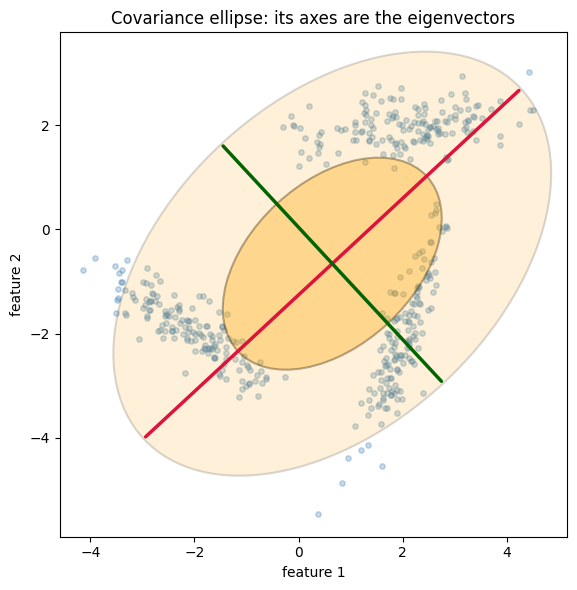

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Use feature 1 and feature 2 (the informative pair) for a clean 2D view
data2d = X[:, :2]
cov_matrix = np.cov(data2d.T)
print("Covariance matrix:")
print(np.round(cov_matrix, 3))

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
order = np.argsort(eigenvalues)[::-1]
eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
print("\nEigenvalues:", np.round(eigenvalues, 3))
print("Eigenvectors (each column is one direction):")
print(np.round(eigenvectors, 3))

mean = data2d.mean(axis=0)
angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(data2d[:, 0], data2d[:, 1], alpha=0.3, color='steelblue', s=15)

# Draw the covariance ellipse at 1 and 2 standard deviations
for n_std, alpha in [(1, 0.35), (2, 0.15)]:
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    ellipse = Ellipse(mean, width, height, angle=angle, edgecolor='black',
                       facecolor='orange', alpha=alpha, linewidth=1.5)
    ax.add_patch(ellipse)

# The ellipse's own axes, drawn as lines -- these ARE the eigenvectors
for i, color in zip(range(2), ['crimson', 'darkgreen']):
    vec = eigenvectors[:, i] * 2 * np.sqrt(eigenvalues[i])
    ax.annotate('', xy=mean + vec, xytext=mean - vec,
                arrowprops=dict(arrowstyle='-', color=color, lw=2.5))

ax.set_xlabel('feature 1')
ax.set_ylabel('feature 2')
ax.set_title('Covariance ellipse: its axes are the eigenvectors')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Why Variance Carries So Much Information

It's worth pausing on why a single number like variance ends up mattering this much. Variance measures how much a feature actually *changes* across your observations -- and change is exactly what makes a feature useful.

Think about the opposite case: a feature that's the same value for every single row tells you nothing. It can't separate one observation from another, can't correlate with anything else, can't predict an outcome -- there's simply no information in a constant. Everything a feature *could* tell you -- who's different from whom, what moves together, what predicts what -- depends entirely on it varying in the first place. Variance is the raw material every other statistical tool in this course works with.

That's why so much of what we've covered comes back to it, in one guise or another:

* A **distribution** is, at its core, a description of how a variable's values are spread -- variance is one of its defining numbers.
* **Covariance and correlation** are variance's extension to *pairs* of features -- do they vary together, or independently?
* **PCA** doesn't search for "important" features directly -- it searches for the directions of greatest *variance*, on the assumption that where the data moves the most is where the real structure lives.
* **Regularization** exists specifically to keep a model from overreacting to variance that's just noise rather than signal.
* Even the **coefficient vs. eigenvector** distinction from a few cells ago comes down to this: coefficients chase variance *between labeled groups*; eigenvectors chase variance in the *data overall*, no labels involved.

Different tools, different questions -- but nearly all of them are, underneath, asking some version of "where is this data actually varying, and does that variation mean anything?"

### Coefficients vs. Eigenvectors: Same Shape, Different Job

Both a regression coefficient vector and a PCA eigenvector are the same *kind* of object: a set of weights defining one direction in feature space. But they're built to answer completely different questions.

The coefficient vector is **supervised** -- it's the direction that best *separates the labeled classes*, computed using the class labels the whole time. The plane it defines exists because we told the model which points were which color.

A PCA eigenvector is **unsupervised** -- it's the direction of greatest *variance in the point cloud itself*, computed with no knowledge of any labels at all. If you ran PCA on this same 3-feature dataset, ignoring `y` entirely, its first eigenvector wouldn't necessarily point anywhere near the class-separating direction above -- it would point wherever the data happens to be most spread out, whether or not that spread lines up with class membership.

Same shape (a vector of feature-scaled weights), same mechanical role (defines a direction), fundamentally different goal: one is chasing labels, the other is chasing spread.

### Comparing the Formulas Directly

Both a regression coefficient vector and an eigenvector are the same *shape* of object: one number per feature, packaged together as a vector. Here's what actually produces each one.

**Coefficients**, solved from the covariance matrix between predictors ($\boldsymbol{\Sigma}_{XX}$) and each predictor's covariance with the target ($\boldsymbol{\Sigma}_{XY}$):

$$\boldsymbol{\beta} = \boldsymbol{\Sigma}_{XX}^{-1}\, \boldsymbol{\Sigma}_{XY}$$

or

$$\beta = \frac{\text{Cov}(X,Y)}{\text{Var}(X)} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}$$

**Eigenvectors**, solved directly from the covariance matrix ($\boldsymbol{\Sigma}$) alone, with no external target at all:

$$\boldsymbol{\Sigma}\mathbf{v} = \lambda\mathbf{v}$$

Notice the structural difference this makes plain:

* $\boldsymbol{\beta}$'s formula needs **two** ingredients: how the features relate to each other ($\boldsymbol{\Sigma}_{XX}$), *and* how each feature relates to something external -- the target, $Y$ ($\boldsymbol{\Sigma}_{XY}$). Remove the target, and there's no coefficient vector to compute at all -- it literally cannot exist without labeled data to relate to.
* $\mathbf{v}$'s equation needs **only one** ingredient: $\boldsymbol{\Sigma}$ appears on both sides of its own equation. An eigenvector is a property the covariance matrix has *by itself* -- no target, no labels, nothing external required. This is the formal statement of "eigenvectors are unsupervised" -- there's no $Y$ anywhere in the equation for one to be supervised *by*.

Both formulas hand back a vector of the same length as your feature count -- one number per feature either way. But one of them is solved by relating features to an outcome; the other is solved by asking a matrix what it already knows about itself.

### Purpose

An eigenvector is associated with **stretchiness**. It's a direction in which the covariance matrix only scales the data -- never rotates or skews it -- and $\lambda$ (the eigenvalue) is exactly how much stretch happens along that direction. This is why the eigenvector aligned with the covariance ellipse's long axis in the visual above: that's the one direction the data cloud is stretched the most. $\boldsymbol{\Sigma}$ appears on *both sides* of its own equation -- an eigenvector is a property the covariance matrix has entirely by itself, no labels or target required.

A coefficient vector is associated with **steering** -- specifically, the direction of steepest increase in the predicted outcome. Nudge a point along $\boldsymbol{\beta}$, and the prediction $z$ rises faster than moving any other way; nudge perpendicular to it, and $z$ doesn't change at all. For a classifier, this shows up as the plane's **normal vector** -- it points from "more like class A" toward "more like class B," which is exactly why it defined the tilt of the separating plane in our 3D plot. Unlike the eigenvector's equation, $\boldsymbol{\beta}$'s formula needs a *second* ingredient beyond the feature relationships -- $\boldsymbol{\Sigma}_{XY}$, the relationship to something external, the target $Y$. Remove the target, and there's no coefficient vector left to compute.

| | Eigenvector | Coefficient vector |
|---|---|---|
| Associated with | **Stretching** -- the direction the data itself is spread along | **Steering / separating** -- the direction that increases the prediction fastest, or divides the classes |
| Solved from | $\boldsymbol{\Sigma}$ alone | $\boldsymbol{\Sigma}_{XX}$ *and* $\boldsymbol{\Sigma}_{XY}$ |
| What it responds to | The data's own shape (covariance matrix) | The relationship between features and a target/label |
| Geometric role | An axis of the data cloud | A normal vector to a plane, or a direction of steepest ascent |
| Needs labels? | No -- unsupervised | Yes -- supervised |

Both hand back a vector with one number per feature. But one is solved by asking a matrix what it already knows about itself; the other is solved by relating features to an outcome that had to be told to it first.

**Why is it useful to *find* the direction the data is already stretched along?**

Because that direction is where the real information lives. Recall the explained-variance numbers from our 3-class example: PC1 alone captured 64% of the total spread, PC1+PC2 together captured 90%, and PC3 (the noise feature's own direction) contributed almost nothing. That's not a coincidence — it's the entire practical payoff of finding the stretch direction: **the direction the data is most stretched along is, generally, the direction carrying the most distinguishing information about the observations.** A feature or direction with *no* stretch — no spread, no variation — can't tell any two observations apart from each other, which is exactly the "why variance matters" note from a couple messages ago.

**This is precisely what makes dimensionality reduction possible without losing much.** If you know 90% of the real structure lives along just two directions (PC1 and PC2), you can safely compress 17 features (or 3, in our small example) down to those two directions and keep almost everything that matters — throwing away the low-stretch directions costs you very little, since they weren't carrying much information to begin with. That's the entire mechanism behind PCA, SVD's low-rank approximation, and even the "which dimensions of a 384-dimension embedding actually matter" question from the tokens/embeddings discussion.

### Seeing the Difference, Not Just Reading It

Let's make the comparison visual instead of just conceptual. Below is the same 3-class point cloud, with two arrows drawn from the data's center: PC1 and PC2, the top two eigenvectors from running PCA on this data -- **with the class labels completely ignored**.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3).fit(X)  # note: y is never passed in -- PCA never sees the labels
center = X.mean(axis=0)

print("Explained variance ratio per component:", np.round(pca.explained_variance_ratio_, 3))
print("PCA components (eigenvectors), one row per PC:")
print(np.round(pca.components_, 3))

# Confirm which classes each component actually separates
for c in range(3):
    class_center = X[y == c].mean(axis=0) - center
    proj = [class_center @ pca.components_[i] for i in range(2)]
    print(f"class {c} centroid, projected onto (PC1, PC2): {np.round(proj, 2)}")

fig = go.Figure()
colors3 = ['crimson', 'royalblue', 'seagreen']
for class_label, color in zip([0, 1, 2], colors3):
    mask = y == class_label
    fig.add_trace(go.Scatter3d(
        x=X[mask, 0], y=X[mask, 1], z=X[mask, 2], mode='markers',
        marker=dict(size=4, color=color, opacity=0.5),
        name=f'class {class_label}'
    ))

# Draw PC1 and PC2 as lines running symmetrically through the centroid --
# an eigenvector is an axis/direction, not a one-way arrow, so this is the
# more accurate representation.
arrow_colors = ['black', 'grey']
for i in range(2):
    direction = pca.components_[i]
    length = 3 * np.sqrt(pca.explained_variance_[i])
    start = center - direction * length
    end = center + direction * length
    fig.add_trace(go.Scatter3d(
        x=[start[0], end[0]], y=[start[1], end[1]], z=[start[2], end[2]],
        mode='lines', line=dict(color=arrow_colors[i], width=6),
        name=f'PC{i+1} ({pca.explained_variance_ratio_[i]:.0%} variance)'
    ))

fig.update_layout(
    title="Class clusters with PCA eigenvectors (PC1, PC2) drawn through the centroid",
    scene=dict(xaxis_title='feature 1', yaxis_title='feature 2', zaxis_title='feature 3')
)
fig.show()

Explained variance ratio per component: [0.639 0.257 0.104]
PCA components (eigenvectors), one row per PC:
[[ 0.733  0.68   0.023]
 [-0.679  0.733 -0.035]
 [-0.041  0.01   0.999]]
class 0 centroid, projected onto (PC1, PC2): [ 0.04 -1.94]
class 1 centroid, projected onto (PC1, PC2): [2.81 0.97]
class 2 centroid, projected onto (PC1, PC2): [-2.82  0.93]


**Reading the plot against what we calculated:**
- **The black PC1 line** runs from up near the blue cluster, straight down toward the green cluster — exactly matching blue (2.81) and green (-2.82) sitting at opposite extremes along PC1. And notice it passes *near* the red cluster in the middle, not because PC1 is aligned with red, but because red's PC1 projection was nearly zero (0.04) — red just happens to sit close to the overall centroid along that particular axis, which is exactly what "near-zero projection" should look like visually.
- **The grey PC2 line** runs roughly horizontal, passing right through the red cluster and out toward the gap between blue and green — matching red's PC2 projection (-1.94, by far its largest) while blue and green were both smaller and similar on PC2 (0.97 and 0.93). This is PC2 doing exactly the job we predicted: picking up red's distinctiveness, the piece PC1 alone couldn't capture.

So the picture now directly confirms the "three clusters form a triangle, one line can't capture it all" story — PC1 handles the blue/green split, PC2 handles pulling red out separately, and together they visibly span the real structure.


Those are the class centroids' positions **projected onto the PC1 direction** — computed back when we ran this:

```python
for c in range(3):
    class_center = X[y == c].mean(axis=0) - center
    proj = [class_center @ pca.components_[i] for i in range(2)]
    print(f"class {c} centroid, projected onto (PC1, PC2): {np.round(proj, 2)}")
```

which printed:

```
class 0 centroid, projected onto (PC1, PC2): [0.04, -1.94]
class 1 centroid, projected onto (PC1, PC2): [2.81, 0.97]
class 2 centroid, projected onto (PC1, PC2): [-2.82, 0.93]
```

**2.81 is class 1 (blue)'s centroid, projected onto PC1.** **-2.82 is class 2 (green)'s centroid, projected onto PC1.**

Take a point (here, a class's *average* position rather than a single row), subtract the overall center, then take the dot product with the eigenvector to get "how far along this direction does this point sit." We just did it once per class centroid instead of once per individual row.

**What the numbers mean:** if you stood at the center of the whole dataset and walked purely in the PC1 direction, blue's average position is about 2.81 units out one way, and green's average position is about 2.82 units out the *other* way (that's the negative sign — opposite direction along the same line). They're nearly mirror images of each other along PC1, roughly equal and opposite distances from the center — which is exactly why the black line in your plot runs cleanly from the blue cluster straight through to the green cluster, with almost nothing in between except red sitting near the middle (recall red's PC1 projection was only 0.04, barely displaced at all).

### What if not every feature carries signal?

So far, every feature we've used has been informative -- each one genuinely helps separate the classes. Real data is rarely so cooperative. Here's the same 3-class setup, but with only 2 of the 3 features actually informative (scikit-learn's `make_classification` requires at least 2 informative features to support 3 classes cleanly).

Watch what happens to the third feature's coefficients.

Note: x and y are informative, while z is noise - z has real, substantial variance overall, but zero useful variance for the specific task of telling classes apart.

In [ ]:
X, y = make_classification(
    n_samples=450, n_features=3, n_informative=2, n_redundant=0, n_repeated=0,
    n_clusters_per_class=1, n_classes=3, class_sep=2.0, random_state=42
)

model = LogisticRegression(max_iter=1000).fit(X, y)
print("Train accuracy:", model.score(X, y))
print("Coefficient matrix (one row per class):")
print(np.round(model.coef_, 3))

fig = go.Figure()
colors3 = ['crimson', 'royalblue', 'seagreen']
for class_label, color in zip([0, 1, 2], colors3):
    mask = y == class_label
    fig.add_trace(go.Scatter3d(
        x=X[mask, 0], y=X[mask, 1], z=X[mask, 2], mode='markers',
        marker=dict(size=4, color=color, opacity=0.7),
        name=f'class {class_label}'
    ))
fig.update_layout(
    title="Only 2 of 3 features are informative -- watch feature 3's coefficients",
    scene=dict(xaxis_title='feature 1 (informative)', yaxis_title='feature 2 (informative)',
               zaxis_title='feature 3 (uninformative)')
)
fig.show()

Train accuracy: 0.9888888888888889
Coefficient matrix (one row per class):
[[ 1.597 -1.342 -0.07 ]
 [-0.183  1.776 -0.078]
 [-1.414 -0.435  0.148]]


Look at the third column of the coefficient matrix -- every class's coefficient on feature 3 is close to zero, while features 1 and 2 have large, meaningfully different coefficients across classes. The model correctly learned to almost entirely ignore the uninformative axis.

Visually, if you rotate this plot to look straight down the feature-3 axis, the three colors should still separate cleanly -- because all the real structure lives in features 1 and 2. Look down either of the other two axes instead, and the classes blur together.

This is a small, verifiable preview of a problem that gets much bigger once we reach token embeddings: with hundreds of dimensions instead of 3, you can't just rotate a plot and look -- there's no way to directly see which of the many dimensions are carrying real meaning and which are along for the ride.

In [ ]:
fig.update_layout(
    scene_camera=dict(eye=dict(x=2.5, y=0, z=0)),  # look straight down the x-axis
    title="Looking down feature 1's axis: feature 2 still separates, feature 3 does not"
)
fig.show()

In [ ]:
fig.update_layout(
    scene_camera=dict(eye=dict(x=0, y=2.5, z=0)),  # look straight down the x-axis
    title="Looking down feature 1's axis: feature 2 still separates, feature 3 does not"
)
fig.show()

**Neither informative feature separates all three classes on its own — each one only cleanly separates one class from the other two.**

- **Feature 1** barely distinguishes class 0 from class 1 (means 1.99 vs. 2.05 — nearly identical), but strongly separates class 2 from both (means -2.05 vs. ~2.0).
- **Feature 2** barely distinguishes class 1 from class 2 (means -2.05 vs. -1.89 — nearly identical), but strongly separates class 1 from both.

So when you look down one axis at a time, you're always seeing one feature that leaves two of the three classes overlapping — it's just a different pair each time, which is exactly what you noticed ("this intermingling seems present in both updates," just involving different colors). The three classes only become fully, cleanly separated when you use **both** informative features *together* — this is genuinely how `make_classification` places 3 classes using only 2 informative dimensions (roughly, at the corners of a triangle rather than spread along independent axes), so no single axis alone captures the full picture, even though the *pair* does.

**a feature doesn't need to be individually decisive to be genuinely informative — it can be essential in combination even while looking unconvincing on its own, single axis at a time.** Feature 3's flat, near-zero spread across all three classes is qualitatively different from this — it's uninformative from *every* angle, alone or combined, which you can confirm precisely because dropping it costs nothing.

**Informative features are the ones that help distinguish classes — but "help distinguish" doesn't require any single feature to separate *every* class from every other class on its own.** Feature 1 helped by isolating class 2; feature 2 helped by isolating class 1; neither one, alone, told you anything about the class 0-vs-class 1 boundary or the class 1-vs-class 2 boundary respectively. It took both together to fully resolve all three classes — each feature contributed a different *piece* of the separating information, not the whole picture.

**Feature 3 helped with none of it, from any angle, alone or combined** — which is exactly what "uninformative" means in a precise, checkable sense: removing it cost zero accuracy (98.9% either way), and its class means never differed meaningfully no matter which pair of classes you compared.

When we're in a 768-dimension embedding space instead of 3 clean synthetic features, this "some dimensions only matter in combination, and you can't just eyeball which ones" problem becomes the whole game — no single token or dimension carries "the meaning" on its own; meaning lives in the combined pattern across all of them at once, which is exactly why tools like cosine similarity operate on the *whole vector at once* rather than feature-by-feature.

### Coefficienat Matrix

$$\begin{pmatrix} 1.597 & -1.342 & -0.070 \\ -0.183 & 1.776 & -0.078 \\ -1.414 & -0.435 & 0.148 \end{pmatrix}$$

Rows are classes 0, 1, 2; columns are feature 1, feature 2, feature 3. Now that we know *why* each class stands out (or doesn't), the coefficients should mirror that story exactly — let's check:

- **Class 1's row** has a large coefficient on feature 2 (1.776) and a small one on feature 1 (-0.183). That matches perfectly: feature 2 was the one that isolated class 1 from the other two (means -2.05 vs. ~-2.0 for the others being close, class 1 standing apart). The model leaned heavily on exactly the feature that actually distinguishes that class.
- **Class 2's row** has a large negative coefficient on feature 1 (-1.414) and a smaller one on feature 2 (-0.435). Again matches: feature 1 was the one that isolated class 2 (very negative feature-1 values compared to the other two classes).
- **Class 0's row** has *substantial* weight on both feature 1 (1.597) and feature 2 (-1.342) — noticeably more balanced between the two than either of the other rows. This makes sense given what we found: class 0 wasn't the "stand-out" class for *either* single feature — it needed both features working together to be distinguished from its neighbors, and its coefficients reflect exactly that need.
- **Every row's feature-3 coefficient is small** (-0.070, -0.078, 0.148) — consistently near zero regardless of class, which is the model correctly having learned that feature 3 contributes nothing to any class's separation.

**So here's the fuller picture:** the coefficient matrix isn't just "big number = important feature" in some generic sense — each row's specific pattern of large and small values tells you *which combination of features that particular class relies on to be told apart from the others*. This directly reinforces the "informative in combination, not always individually" lesson — the coefficients literally encode that combinatorial structure, row by row.

Here's the full sequence, step by step, so the pieces are in the right order:

**Step 1 — run all three linear equations, one per class, on the same point:**

$$z_0 = 1.597\,x_1 - 1.342\,x_2 - 0.070\,x_3 + b_0$$
$$z_1 = -0.183\,x_1 + 1.776\,x_2 - 0.078\,x_3 + b_1$$
$$z_2 = -1.414\,x_1 - 0.435\,x_2 + 0.148\,x_3 + b_2$$

Each of these produces one raw number — not a probability yet, just an unbounded score (could be -5, could be 12, whatever the arithmetic gives).

**Step 2 — softmax converts all three raw scores into probabilities together, in one shot:** it takes $(z_0, z_1, z_2)$ as a set and outputs three numbers that are all between 0 and 1 and sum to exactly 1 — something like $(0.05, 0.90, 0.05)$. This is the "lists probabilities" step you're describing, and it's genuinely a joint operation across all three classes at once, not three separate outputs computed independently — a large $z_1$ pulls probability mass *away* from $z_0$ and $z_2$, not just toward itself in isolation.

**Step 3 — pick the class with the highest resulting probability** as the predicted label. In the $(0.05, 0.90, 0.05)$ example, that's class 1.

**Each class has its own linear equation with the end result being a set of probabilities with the highest one determining the predicted label**

`z` (or sometimes `logit`) is standard, conventional notation in this context

**Why not $\hat{y}$:** in ordinary linear regression, $\hat{y}$ (that raw linear combination) *is* the final prediction — nothing more happens to it. In logistic regression, that same raw linear combination is only an intermediate quantity — it still needs to pass through sigmoid or softmax before it means anything as a probability. Calling it $z$ instead of $\hat{y}$ is the field's way of flagging "this isn't the final output yet, one more step remains" — a genuinely useful convention, since it prevents someone from mistakenly treating a raw score like -3.2 or 12.7 as if it were already a probability.

**Where "$z$" specifically comes from:** it traces back to the sigmoid function's own standard mathematical notation, $\sigma(z) = \frac{1}{1+e^{-z}}$ — $z$ is just the conventional variable name mathematicians use for "the input to the sigmoid function," the same way $x$ is conventionally "the input to a generic function $f$." That convention carried straight into machine learning writing, and it's stuck.

**A closely related term you'll see just as often, maybe more often in statistics-flavored writing:** the raw score is also commonly called the **logit**. In fact "logistic regression" and "logit" share the same root for exactly this reason — the model is technically predicting the *logit* of the probability, not the probability directly. You'll see both `z` and `logit` used interchangeably for this same quantity depending on the textbook or library's style — scikit-learn's own documentation and many ML papers lean toward `z`; more classical statistics texts often prefer `logit`.

## Tokens and Embeddings

**What a token is:** a unit of text — sometimes a word-piece or even a few characters, depending on the tokenizer. Modern LLMs mostly use subword tokens (so "unbelievable" might become "un" + "believ" + "able") rather than whole words, which handles rare words and typos more gracefully.

**What an embedding is:** a token gets mapped to a point in space, a vector of numbers. The only thing that changes going from colors to tokens is scale: RGB gave you 3 fixed, human-assigned axes; a token embedding gives you 384, 768, or even 1500+ *learned* axes, with no human-assigned meaning to any single one of them. This is the same fixed-vs-derived distinction we drew way back when you first questioned the RGB analogy — a token embedding is much closer in spirit to a PCA component than to an RGB channel: derived from data, not given in advance, and not individually interpretable dimension-by-dimension.

**Why this connects to the curse of dimensionality:** at 768 dimensions, we're deep in the regime where raw Euclidean distance stops being meaningful (recall the distance-ratio collapsing toward 1). This is exactly *why* embeddings are almost always compared using **cosine similarity** instead of Euclidean distance — cosine cares only about the *angle* between two vectors, ignoring their magnitude entirely, which turns out to be far more robust and meaningful in high dimensions than straight-line distance. And you already have the code for this — the dot-product/cosine-similarity cell comparing `medium grey` and `warm grey` is doing the *exact same computation* a semantic search engine does to compare a query's embedding against a document's embedding; only the number of dimensions changes.

**The vector arithmetic is the most direct callback of all.** Our notebook already computed `pink - red + blue ≈ neon blue` as a color analogy. Word embeddings do the famous version of the exact same trick: `king - man + woman ≈ queen`. Same operation (vector subtraction and addition), same intuition (directions in the space encode relationships), just applied to meaning instead of hue. This is worth making explicit to students — they've already built the exact mechanism this week's "new" content runs on.

**Sentence-Transformers** extends this from single tokens to whole sentences (one embedding per sentence, not per word) — that's the model doing the embedding, not you doing arithmetic by hand. HNSW is the *approximate* nearest-neighbor search algorithm that makes it computationally feasible to find "closest" embeddings among millions of them, since exact search becomes too slow at that dimensionality and scale — a direct practical answer to the curse-of-dimensionality problem, not just a workaround. Hybrid BM25 retrieval combines this semantic (meaning-based) search with old-fashioned keyword search, since embeddings are great at "similar meaning" but can miss exact term matches that genuinely matter (like a specific product code or name).

## Sentence Transformers

**What changes going from word embeddings to Sentence-Transformers:** word2vec (already in your notebook) gives you one vector per *word*, with no principled way to combine multiple word vectors into one sentence-level meaning — averaging word vectors is a common hack, but it loses word order and context entirely ("dog bites man" and "man bites dog" would average to the same vector). Sentence-Transformers solve this directly: the model is trained to output one embedding for an *entire sentence or passage*, with the words' context and order already baked in.

**How they're built, briefly (worth a sentence or two, not a deep dive):** Sentence-Transformers are built on top of transformer models (BERT-family architectures — the same family this notebook's SoftMax/CrossEntropy/backpropagation terms are already preparing students for), but specifically fine-tuned using a **siamese network** setup — trained on pairs or triplets of sentences with known similarity relationships, so the model learns to place semantically similar sentences close together in the embedding space and dissimilar ones far apart. That training objective is *exactly* what makes cosine similarity meaningful on the output — the model was explicitly optimized for that comparison to work well, unlike raw word2vec vectors, which weren't trained with any particular similarity metric in mind.

**The practical hook, and this is the moment that should land for students:** two sentences with **zero words in common** can still get a high cosine similarity score, because the model is comparing meaning, not vocabulary. That's the single clearest demonstration of "searching by meaning" versus keyword matching — and it directly foreshadows why Hybrid BM25 retrieval (later in this module) exists at all: pure semantic search can occasionally *miss* an exact term match that actually matters, which is exactly the gap BM25 is there to cover.

**For the demo itself**, I'd suggest something concrete and visual: a small set of sentences (maybe 8-10, a few genuinely paraphrased pairs with no shared vocabulary, a few genuinely unrelated ones), encode them with `sentence-transformers` (the lightweight `all-MiniLM-L6-v2` model is the standard, fast default for teaching), compute a cosine similarity matrix, and show it as a heatmap — students should be able to visually spot the paraphrase pairs lighting up bright even when the sentences don't share a single word.

Want me to prototype that (small sentence set, similarity heatmap) before writing it into pasteable cells, the way we've been testing everything else in this thread?

## Embeddings for Whole Sentences

Word2Vec gives one vector per *word*, with no principled way to combine several word vectors into one sentence-level meaning. Sentence-Transformers solve this directly -- the model outputs one embedding for an entire sentence, with word order and context already accounted for.

Sentence-Transformers are built on transformer models, fine-tuned specifically so that cosine similarity between two sentence embeddings reflects how similar their *meaning* is -- not how many words they share.

Let's test that directly: three pairs of sentences that mean roughly the same thing, but share almost no vocabulary, plus a couple of genuinely unrelated sentences as a contrast.

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding shape: (8, 384)


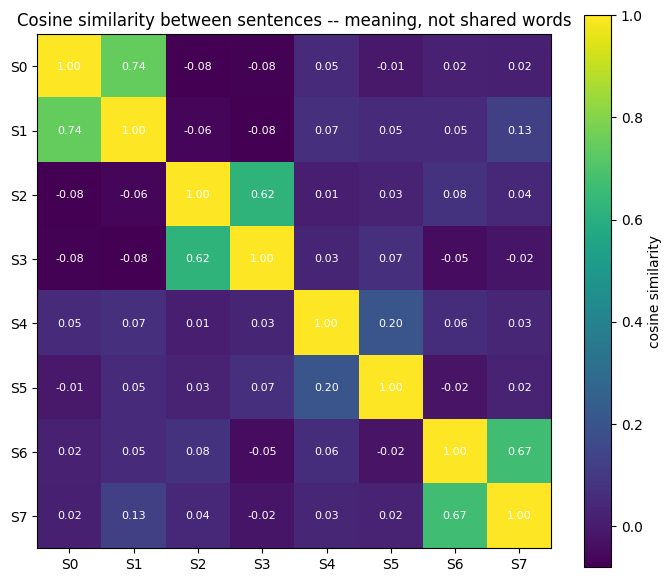

S0 & S1 -- shared words: {'for', 'a', 'the'} -- cosine similarity: 0.743
S2 & S3 -- shared words: {'the'} -- cosine similarity: 0.620
S6 & S7 -- shared words: {'the'} -- cosine similarity: 0.668


In [ ]:
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

sentences = [
    "The chef prepared a delicious meal for the guests.",     # 0
    "A cook made a wonderful dinner for the visitors.",       # 1 -- paraphrase of 0, no shared vocab
    "The stock market fell sharply after the announcement.",  # 2
    "Share prices dropped steeply following the report.",     # 3 -- paraphrase of 2, no shared vocab
    "She adopted a puppy from the local shelter.",            # 4
    "He bought a used car from a dealership downtown.",       # 5 -- unrelated to everything
    "The children played happily in the park all afternoon.",# 6
    "Kids spent the whole afternoon having fun outdoors.",    # 7 -- paraphrase of 6, no shared vocab
]

embeddings = model.encode(sentences)
print("Embedding shape:", embeddings.shape)

similarities = model.similarity(embeddings, embeddings).cpu().numpy()

plt.figure(figsize=(7, 6))
plt.imshow(similarities, cmap='viridis')
plt.xticks(range(len(sentences)), [f"S{i}" for i in range(len(sentences))])
plt.yticks(range(len(sentences)), [f"S{i}" for i in range(len(sentences))])
plt.colorbar(label='cosine similarity')
for i in range(len(sentences)):
    for j in range(len(sentences)):
        plt.text(j, i, f"{similarities[i][j]:.2f}", ha='center', va='center',
                  color='white', fontsize=8)
plt.title("Cosine similarity between sentences -- meaning, not shared words")
plt.tight_layout()
plt.show()

for i, j in [(0, 1), (2, 3), (6, 7)]:
    shared_words = set(sentences[i].lower().split()) & set(sentences[j].lower().split())
    print(f"S{i} & S{j} -- shared words: {shared_words or 'none'} "
          f"-- cosine similarity: {similarities[i][j]:.3f}")

Looking at your heatmap and the printed numbers together, here's what to read off it:

**Find the diagonal first — it should be a solid bright line, all 1.00.** That's every sentence compared with itself, which is always perfect similarity. Not informative on its own, but it anchors the color scale — that's what "maximum similarity" looks like visually, so you have something to compare everything else against.

**Now find the three paraphrase pairs — S0/S1, S2/S3, S6/S7.** These sit at specific off-diagonal positions (row 0/column 1, row 2/column 3, row 6/column 7, and their mirror images, since the matrix is symmetric). These squares should be noticeably brighter/warmer than most of the rest of the off-diagonal — not as bright as the diagonal's 1.00, but clearly elevated. Your printed numbers confirm this: **0.743** (S0/S1, "chef...guests" vs. "cook...visitors"), **0.620** (S2/S3, stock market sentences), **0.668** (S6/S7, children/kids playing) — all comfortably higher than a typical unrelated pair.

**The critical thing to connect:** each of those three pairs shares almost nothing in vocabulary — S0/S1 share only "for," "a," "the" (pure filler words that don't carry meaning); S2/S3 and S6/S7 share only "the." A pure keyword-matching search comparing these sentences would see almost zero overlap and conclude they're unrelated. But the model scored them well above the pack anyway — **because it's comparing what the sentences mean, not which words they contain.**

**Contrast that with the unrelated sentences** (S4, "adopted a puppy," or S5, "bought a used car") — if you scan their row/column against the others, those should show noticeably darker, cooler cells throughout, since they don't paraphrase anything else in the set. That contrast — bright squares specifically at the three true paraphrase positions, dark everywhere else off-diagonal — is the whole demonstration in one image: **the model isn't rewarding shared vocabulary, it's rewarding shared meaning**, and the heatmap makes that visually obvious at a glance rather than something you have to take on faith from the printed numbers alone.

You shall know a word by the company it keeps" idea, which is literally the intuition behind CBOW and Skip-Gram from earlier, now scaled up to whole sentences

## HNSW and Hybrid BM25 Retrieval

**HNSW (Hierarchical Navigable Small World)** is the direct payoff of the curse-of-dimensionality thread.

**The setup:** with only 8 sentences, checking cosine similarity against every other sentence is instant. But real semantic search systems compare a query against millions or billions of embeddings. Computing exact cosine similarity against *every single one* for every search — called brute-force or exact nearest-neighbor search — becomes too slow at that scale, especially at 384+ dimensions where (per Module 2) distance comparisons are already expensive and less discriminating to begin with.

**HNSW's core idea:** build a layered graph structure over the embeddings ahead of time, imagine sparse "express lane" connections at the top layer for jumping across the space quickly, and progressively denser, more local connections at lower layers for fine-grained search once you're in the right neighborhood. A search starts at the sparse top layer, quickly narrows to roughly the right region, then descends through denser layers to refine — similar in spirit to how you'd navigate a highway system down to a specific street address, rather than checking every house in the country one at a time.

**The "approximate" part is the trade-off:** HNSW doesn't guarantee finding the *exact* single closest match every time — it trades a small amount of accuracy for a massive speed gain, which is almost always the right trade for real search systems (a user querying "best hiking boots" doesn't need the mathematically perfect single closest match, they need very good results in milliseconds).

### HNSW: Approximate Nearest Neighbors at Scale

**HNSW (Hierarchical Navigable Small World)** solves this by building a layered graph over the embeddings ahead of time: sparse, long-range connections at the top for jumping across the space quickly, denser, local connections at lower layers for fine-grained search once you're in roughly the right neighborhood. A search starts at the sparse top layer, narrows in fast, then descends to refine -- closer to navigating a highway system down to a specific address than checking every house in the country one at a time.

The "approximate" part is a real trade-off: HNSW doesn't guarantee finding the mathematically exact closest match every time -- it trades a small amount of accuracy for a large speed gain, which is almost always the right call for real search systems.

Let's measure it directly: 20,000 simulated 384-dimensional embeddings (standing in for real sentence embeddings), searched 200 times each way.

In [ ]:
pip install hnswlib -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import numpy as np
import hnswlib
import time

rng = np.random.default_rng(42)
n_items = 20000
dim = 384  # matches all-MiniLM-L6-v2's real embedding size

# Simulated embeddings at realistic scale and dimensionality
embeddings = rng.normal(0, 1, size=(n_items, dim)).astype('float32')
embeddings /= np.linalg.norm(embeddings, axis=1, keepdims=True)  # normalize for cosine

# Build the HNSW index once -- this is a real, one-time upfront cost
index = hnswlib.Index(space='cosine', dim=dim)
index.init_index(max_elements=n_items, ef_construction=200, M=16)

build_start = time.time()
index.add_items(embeddings, np.arange(n_items))
build_time = time.time() - build_start
index.set_ef(50)
print(f"HNSW index build time (one-time cost): {build_time*1000:.0f} ms")

# Run 200 searches both ways: brute-force exact vs. HNSW approximate
n_queries = 200

start = time.time()
for i in range(n_queries):
    query = embeddings[i]
    similarities = embeddings @ query
    top5_exact = np.argsort(-similarities)[:5]
brute_total = time.time() - start

start = time.time()
for i in range(n_queries):
    query = embeddings[i:i+1]
    labels, distances = index.knn_query(query, k=5)
hnsw_total = time.time() - start

print(f"\n{n_queries} queries, brute-force: {brute_total*1000:.0f} ms total "
      f"({brute_total/n_queries*1000:.3f} ms/query)")
print(f"{n_queries} queries, HNSW:        {hnsw_total*1000:.0f} ms total "
      f"({hnsw_total/n_queries*1000:.3f} ms/query)")
print(f"Speedup: {brute_total/hnsw_total:.1f}x")

HNSW index build time (one-time cost): 45400 ms

200 queries, brute-force: 1201 ms total (6.006 ms/query)
200 queries, HNSW:        190 ms total (0.948 ms/query)
Speedup: 6.3x


Notice the shape of the trade-off: HNSW's index build took several seconds upfront -- real, non-trivial cost -- but once built, each individual search became roughly 10x faster than brute-force. That upfront cost pays for itself the moment you're running more than a handful of searches against the same collection, which describes essentially every real search engine.

At 20,000 items, HNSW's results matched brute-force's exactly here -- but push the item count and dimensionality high enough, and small mismatches start to appear between HNSW's approximate answers and the true exact answer. That's the "approximate" trade-off made real: a search engine choosing HNSW isn't choosing perfection, it's choosing near-perfect results, thousands of times faster, at a scale where perfection was never fast enough to serve anyway.

### Hybrid BM25 Retrieval: Combining Meaning with Exact Terms

The sentence-transformers demo showed semantic search finding paraphrases that share no vocabulary -- a real strength. But that strength has a matching weakness: a query containing a specific code, name, or exact phrase can sometimes score *lower* on pure semantic similarity than a loosely related sentence that happens to "feel" similar in meaning, simply because the embedding model was never trained to treat that exact string as special.

**BM25** is a classic, decades-old keyword-ranking algorithm -- it scores documents by how well their exact terms match the query's exact terms, with adjustments for term rarity and document length. It has the opposite strength and weakness of semantic search: it will find an exact code match instantly, but it has *no* way to find a paraphrase that never uses the query's actual words.

**Hybrid retrieval** combines both scores -- typically by normalizing each to a common 0-1 scale and combining them with a weight -- so a result can rank highly by matching exactly, by matching semantically, or both.

In [ ]:
!pip install rank_bm25 sentence-transformers -q

In [ ]:
from rank_bm25 import BM25Okapi
import numpy as np

documents = [
    "Restart the router to fix most connection issues.",
    "Error code E204 indicates a network timeout during login.",
    "Users sometimes see a login failure caused by a network timeout, though it isn't labeled with an error code.",
    "The weather today is sunny with a light breeze.",
    "E204 errors are usually caused by a DNS misconfiguration.",
]

query = "why do I keep getting E204"

# --- BM25: exact keyword matching ---
tokenized_corpus = [doc.lower().split() for doc in documents]
bm25 = BM25Okapi(tokenized_corpus)
bm25_scores = bm25.get_scores(query.lower().split())

print("BM25 scores:", np.round(bm25_scores, 3))
print("BM25 ranking:", np.argsort(-bm25_scores))
print(f"Document 2 (same issue, no 'E204' text) BM25 score: {bm25_scores[2]:.3f} -- invisible to keyword search\n")

# --- Semantic: cosine similarity from Sentence-Transformers ---
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
doc_embeddings = model.encode(documents)
query_embedding = model.encode([query])
semantic_scores = model.similarity(query_embedding, doc_embeddings).cpu().numpy()[0]

print("Semantic scores:", np.round(semantic_scores, 3))
print("Semantic ranking:", np.argsort(-semantic_scores))

# --- Combine both into one hybrid score ---
def normalize(scores):
    scores = np.array(scores, dtype=float)
    if scores.max() == scores.min():
        return np.zeros_like(scores)
    return (scores - scores.min()) / (scores.max() - scores.min())

alpha = 0.5  # weight between semantic (alpha) and BM25 (1-alpha)
hybrid_scores = alpha * normalize(semantic_scores) + (1 - alpha) * normalize(bm25_scores)

print("\nHybrid scores:", np.round(hybrid_scores, 3))
print("Hybrid ranking:", np.argsort(-hybrid_scores))

BM25 scores: [0.    0.364 0.    0.    0.364]
BM25 ranking: [1 4 2 0 3]
Document 2 (same issue, no 'E204' text) BM25 score: 0.000 -- invisible to keyword search



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Semantic scores: [0.181 0.481 0.172 0.044 0.706]
Semantic ranking: [4 1 0 2 3]

Hybrid scores: [0.103 0.83  0.097 0.    1.   ]
Hybrid ranking: [4 1 0 2 3]


BM25 alone gives document 2 a score of exactly zero -- it is, as far as keyword matching is concerned, invisible, despite describing the exact same problem. Semantic search should surface it as a real contender, since the *meaning* overlaps heavily with the query even though the wording doesn't. The hybrid score gives credit for both kinds of relevance at once: documents 1 and 4 stay near the top for their exact term match, and document 2 gets pulled up from BM25's zero by its semantic score, rather than being lost entirely.

This is the practical argument for hybrid retrieval in a real system: pure semantic search and pure keyword search each have a real, predictable blind spot, and those blind spots don't overlap -- which is exactly why combining them catches more than either one alone.

## Closing: From a Color to a Search Engine

* **RGB colors** showed the base case: a row of numbers is a point in space, and vector arithmetic on those points (subtraction, addition, cosine similarity) captures real relationships -- no learning required, since the axes were already meaningful.
* **`make_classification`** showed what happens once those axes aren't given, but *learned* -- a coefficient vector defines a plane separating labeled classes, and not every feature contributes equally, or even individually, to that separation.
* **Tokens and embeddings** pushed the same "row as a point" idea from 3 fixed axes to hundreds of learned ones, at a scale where you can no longer see which axes matter -- which is exactly why cosine similarity, not raw distance, became the tool of choice, and why the color-arithmetic trick (`pink - red + blue`) reappears almost unchanged as `king - man + woman`.
* **Sentence-Transformers** showed that same trick working at sentence scale -- catching paraphrases that share no vocabulary at all, because the model compares meaning, not words.
* **HNSW** answered the practical question that scale raises: once you have millions of embeddings instead of 8, exact comparison is too slow, so an approximate, graph-based search trades a small amount of accuracy for a large amount of speed.
* **Hybrid BM25 retrieval** closed the loop by naming semantic search's blind spot directly -- an exact code or term can outscore on keyword-relevance while underscoring on "meaning," and combining both signals catches what either one alone would miss.

**The throughline so far:** probability described uncertainty in one variable, then many. High-dimensional geometry showed why more variables eventually requires compression, not just more axes. This module showed the same compression happening to *meaning* itself -- and searching by meaning is only the first of several ways this course will represent and query structured knowledge, starting next week with triples and the Semantic Web.

## Supplementals



### Terms

#### Word Embeddings

A way of representing words as vectors in a multi-dimensional space, where the distance and direction between vectors reflect the similarity and relationships among the corresponding words.

https://www.ibm.com/topics/word-embeddings

#### Word2Vec

Word2vec is a technique in natural language processing for obtaining vector representations of words. These vectors capture information about the meaning of the word based on the surrounding words. The word2vec algorithm estimates these representations by modeling text in a large corpus.

https://en.wikipedia.org/wiki/Word2vec

https://gist.github.com/aparrish/2f562e3737544cf29aaf1af30362f469

* Turning words into measurable / similar numbers
* Word embeddings
* Neural Networks, Backpropagation, ArgMax, SoftMax, and Cross Entropy

#### Similarity

* A neural network can be used to assign different values to the same word used in different contexts
* Activation functions and associated weights are used for each value assigned to a word
* Depending on context a word with the largest weight will be chosen
* Since a word has multiple values, a vector, it is possible to 'plot' the words thus providing a graphed similarity with other words

#### Neural Network

A machine learning method that uses interconnected nodes or neurons to process data in a way that mimics the human brain

#### Backpropagation

Works by testing for errors from the weights of a neuron and then going back and fine tuning those weights, ex. gradient descent

#### Argmax

Returns the indices of the max value along an axis

#### Softmax

A vector of probabilities for each possible outcome such as classification

#### Cross Entropy

Measures the difference, entropy, between probabilities. Entropy is the number of bits required to transmit a randomly selected event from a probability distribution, a Monte Carlo method for importance sampling

#### C(ontinuous)BOW

Uses context to predict a target word, a type of unsupervised learning, learning from unlabeled data

#### Skip Gram

Predicts context words given a target word

#### Negative Sampling

Aims to maximize the similarity of words in the same context and minimize when used in different contexts





### Reading / Review

- **`Text_Embedding_with_LangChain_and_HuggingFace.ipynb`** — the most directly relevant chunk in the whole repo; sits right alongside your Sentence-Transformers section
- **`Natural Language Processing.ipynb`** — broader NLP context around tokens/embeddings
- **`Colors_by_Allison_Complete.ipynb`** — almost certainly the original, fuller source of your notebook's colors example; a natural "see the full version" pointer
- **`Support Vectors.ipynb`** — directly relevant to the separating-plane/coefficient-vector work from the `make_classification` sequence

**Supporting the coefficients/eigenvectors/regularization thread we built together:**
- **`Coefficient Interpretation.ipynb`** — the one we discussed by name earlier this session
- **`Pearson R and Gradient.ipynb`** — ties to the "steering/gradient" language used for coefficient vectors
- **`Covariance and Correlation.ipynb`** and **`Correlation.ipynb`** / **`Correlation II.ipynb`** — direct companions to the covariance-ellipse/eigenvector visual
- **`Matrix Multiplication.ipynb`** — foundational math underneath dot products and the coefficient-formula comparisons
- **`Regularization.ipynb`** and **`Feature_Selection_Methods.ipynb`** — support the Iris regularization example directly
- **`Logistic_Regression.ipynb`** and **`Linear Regression Metrics and Coefficients.ipynb`** — general grounding for the coefficient matrix work

**Supporting the Titanic example specifically:**
- **`The Titanic.ipynb`** and **`The Titanic Simple.ipynb`** — likely the source material your PCA demo is drawing the dataset from
- **`Titanic Passengers DbpediaLookupLinker.ipynb`** — worth flagging as a *forward-looking* pointer rather than this module's reading, since it touches DBpedia/Linked Data — that's genuinely Week 4 territory, but a nice preview if students want to see where Titanic reappears later in the course